In [1]:
import torch
from check import setup_torch
# Dummy image-like data: batch=4, channels=1, height=256, width=256
data_dummy = torch.randn(4, 1, 256, 256, dtype=torch.float32)

device = setup_torch()
data_dummy.shape

✅ Using CUDA globally
GPU: NVIDIA GeForce RTX 4090


torch.Size([4, 1, 256, 256])

In [2]:
data_tensor = torch.load("../../json_data/dataset.pt", map_location=device)
data_tensor = [t.flatten() for t in data_tensor]
data_tensor = [t for t in data_tensor if t.numel() == 768000]
data_tensor = [t.reshape((128,6000)) for t in data_tensor]
data_tensor = torch.stack(data_tensor)
data_tensor.shape

torch.Size([103, 128, 6000])

In [4]:
from models.Data_Load import DataLoader_AutoEncoder, Dataset_

dataset = Dataset_(data_tensor,normalize=True)

train_size = 80
test_size = len(dataset) - train_size
gen = torch.Generator(device=device)
train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, test_size], generator=gen
)

dataLoader = DataLoader_AutoEncoder(train_dataset, batch_size=10, shuffle=True)
dataLoader_test = DataLoader_AutoEncoder(test_dataset, batch_size=10, shuffle=False)

In [11]:
from models.Autencoder import AutoEncoder

latent_model = AutoEncoder()
latent_model.to(device)



Loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(latent_model.parameters(), lr=1e-3)
num_epochs = 300
for epoch in range(num_epochs):
    for batch in dataLoader:
        
        batch = batch.to(device)
        output = latent_model(batch)
        loss = Loss_fn(output, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [1/300], Loss: 3726.3286
Epoch [2/300], Loss: 3793.4060
Epoch [3/300], Loss: 3507.4995
Epoch [4/300], Loss: 3700.7905
Epoch [5/300], Loss: 3696.2683
Epoch [6/300], Loss: 3899.0603
Epoch [7/300], Loss: 3474.8928
Epoch [8/300], Loss: 3582.0081
Epoch [9/300], Loss: 3777.4080
Epoch [10/300], Loss: 3610.3704
Epoch [11/300], Loss: 3987.2839
Epoch [12/300], Loss: 3750.1201
Epoch [13/300], Loss: 3674.7781
Epoch [14/300], Loss: 3894.5916
Epoch [15/300], Loss: 3638.1418
Epoch [16/300], Loss: 3351.3535
Epoch [17/300], Loss: 3656.9902
Epoch [18/300], Loss: 3608.6956
Epoch [19/300], Loss: 3703.8369
Epoch [20/300], Loss: 3797.3574
Epoch [21/300], Loss: 3520.3831
Epoch [22/300], Loss: 3437.4446
Epoch [23/300], Loss: 3715.1206
Epoch [24/300], Loss: 3493.1121
Epoch [25/300], Loss: 3716.0625
Epoch [26/300], Loss: 3589.0322
Epoch [27/300], Loss: 3675.5659
Epoch [28/300], Loss: 3474.3137
Epoch [29/300], Loss: 3761.5854
Epoch [30/300], Loss: 3805.7041
Epoch [31/300], Loss: 3529.6365
Epoch [32/300], L

In [6]:

def test_model(model, dataLoader, Loss_fn, optimizer, num_epochs):

    model.eval()
    total_mse = 0.0
    total_mae = 0.0
    num_batches = 0

    output_data = []

    with torch.no_grad():
        for batch in dataLoader:
            batch = batch.to(device)
            output = model(batch)
            total_mse += Loss_fn(output, batch).item()
            total_mae += torch.mean(torch.abs(output - batch)).item()
            num_batches += 1
            output_data.append(output.cpu().numpy())
        

    avg_mse = total_mse / max(1, num_batches)
    avg_mae = total_mae / max(1, num_batches)
    return avg_mse,avg_mae

In [7]:
def plot_(X,Y,x_label='Index',y_label='Value',title='Output Data Plot'):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.plot(X, Y, marker='o')
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid()
    plt.show()

# Example usage:
# Assuming output_data is a list of numpy arrays, we can plot the first one

In [19]:
def train(epoch, lr_rate,dataLoader):
    from models.Autencoder import AutoEncoder

    latent_model = AutoEncoder()
    latent_model.to(device)



    Loss_fn = torch.nn.L1Loss()
    optimizer = torch.optim.Adam(latent_model.parameters(), lr=lr_rate )
    num_epochs = epoch
    for epoch in range(num_epochs):
        for batch in dataLoader:
            
            batch = batch.to(device)
            output = latent_model(batch)
            loss = Loss_fn(output, batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
    return latent_model, Loss_fn, optimizer, num_epochs


In [13]:
lr_rate_list = [1e-5,1e-4,5e-4,1e-3,2e-3,4e-3,5e-3,1e-2,2e-2,4e-2,5e-2,1e-1] 

output_mse = []
output_mae = []
epoch = 300

for lr_rate in lr_rate_list:
    print(f"Training with learning rate: {lr_rate}")
    latent_model, Loss_fn, optimizer, num_epochs = train(epoch, lr_rate, dataLoader)
    avg_mse, avg_mae = test_model(latent_model, dataLoader_test, Loss_fn, optimizer, num_epochs)
    output_mse.append(avg_mse)
    output_mae.append(avg_mae)


Training with learning rate: 1e-05
Epoch [1/300], Loss: 0.3558
Epoch [2/300], Loss: 0.3268
Epoch [3/300], Loss: 0.3629
Epoch [4/300], Loss: 0.3269
Epoch [5/300], Loss: 0.3648
Epoch [6/300], Loss: 0.3651
Epoch [7/300], Loss: 0.3136
Epoch [8/300], Loss: 0.3297
Epoch [9/300], Loss: 0.3359
Epoch [10/300], Loss: 0.3504
Epoch [11/300], Loss: 0.2879
Epoch [12/300], Loss: 0.3127
Epoch [13/300], Loss: 0.3352
Epoch [14/300], Loss: 0.3384
Epoch [15/300], Loss: 0.3352
Epoch [16/300], Loss: 0.3433
Epoch [17/300], Loss: 0.3003
Epoch [18/300], Loss: 0.3399
Epoch [19/300], Loss: 0.3283
Epoch [20/300], Loss: 0.3376
Epoch [21/300], Loss: 0.3497
Epoch [22/300], Loss: 0.3493
Epoch [23/300], Loss: 0.3510
Epoch [24/300], Loss: 0.3319
Epoch [25/300], Loss: 0.3301
Epoch [26/300], Loss: 0.3303
Epoch [27/300], Loss: 0.3262
Epoch [28/300], Loss: 0.3281
Epoch [29/300], Loss: 0.3317
Epoch [30/300], Loss: 0.3251
Epoch [31/300], Loss: 0.3085
Epoch [32/300], Loss: 0.3255
Epoch [33/300], Loss: 0.3248
Epoch [34/300], L

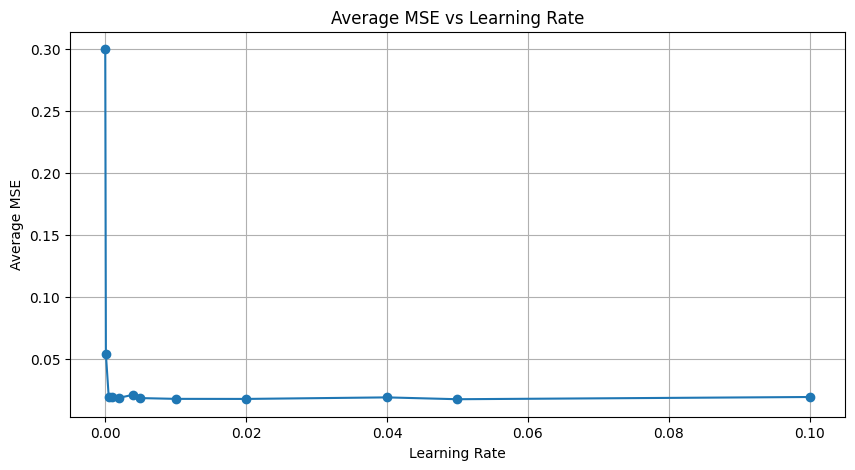

In [14]:
plot_(lr_rate_list, output_mse, x_label='Learning Rate', y_label='Average MSE', title='Average MSE vs Learning Rate')

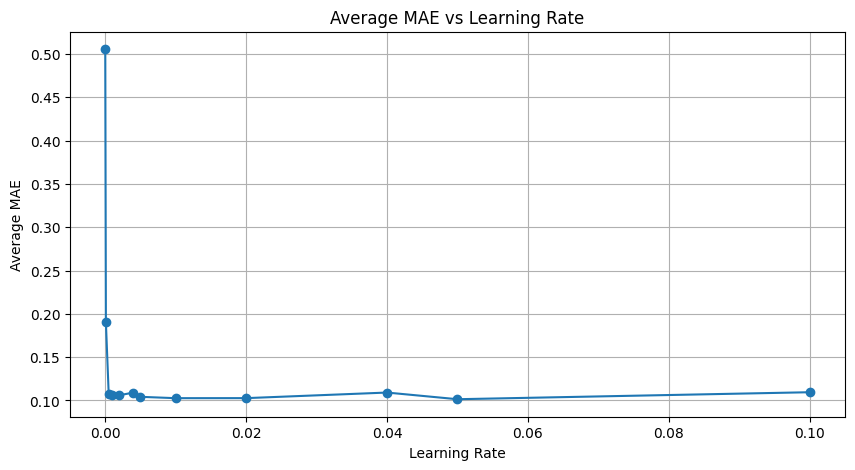

In [15]:
plot_(lr_rate_list, output_mae, x_label='Learning Rate', y_label='Average MAE', title='Average MAE vs Learning Rate')


### LR choice
We can therefore see that the best lr would be 0.005-0.02 this would thus be our choice for the model

In [21]:
lr_rate = 0.008
epoch = 300
latent_model, Loss_fn, optimizer, num_epochs = train(epoch, lr_rate, dataLoader)



Epoch [1/300], Loss: 0.6957
Epoch [2/300], Loss: 0.5360
Epoch [3/300], Loss: 0.4004
Epoch [4/300], Loss: 0.3293
Epoch [5/300], Loss: 0.1959
Epoch [6/300], Loss: 0.1542
Epoch [7/300], Loss: 0.1442
Epoch [8/300], Loss: 0.1354
Epoch [9/300], Loss: 0.1463
Epoch [10/300], Loss: 0.1155
Epoch [11/300], Loss: 0.1333
Epoch [12/300], Loss: 0.1232
Epoch [13/300], Loss: 0.1357
Epoch [14/300], Loss: 0.1275
Epoch [15/300], Loss: 0.1165
Epoch [16/300], Loss: 0.1442
Epoch [17/300], Loss: 0.1237
Epoch [18/300], Loss: 0.1191
Epoch [19/300], Loss: 0.1193
Epoch [20/300], Loss: 0.1189
Epoch [21/300], Loss: 0.1048
Epoch [22/300], Loss: 0.1091
Epoch [23/300], Loss: 0.1119
Epoch [24/300], Loss: 0.1223
Epoch [25/300], Loss: 0.1147
Epoch [26/300], Loss: 0.1127
Epoch [27/300], Loss: 0.1211
Epoch [28/300], Loss: 0.1165
Epoch [29/300], Loss: 0.1145
Epoch [30/300], Loss: 0.1108
Epoch [31/300], Loss: 0.1097
Epoch [32/300], Loss: 0.1182
Epoch [33/300], Loss: 0.1044
Epoch [34/300], Loss: 0.1150
Epoch [35/300], Loss: 0

In [22]:
from matplotlib import pyplot as plt
import matplotlib as mpl


data1 = dataLoader.dataset[0][0]
data1_latent = latent_model.encode_latent(dataLoader.dataset[0].unsqueeze(0))
data_reconstructed = latent_model.decode_latent(data1_latent)[0][0]
data1_latent.shape, data1.shape,data_reconstructed.shape


(torch.Size([1, 128, 2, 94]), torch.Size([128, 6000]), torch.Size([128, 6000]))

(torch.Size([128, 6000]), torch.Size([128, 6000]))

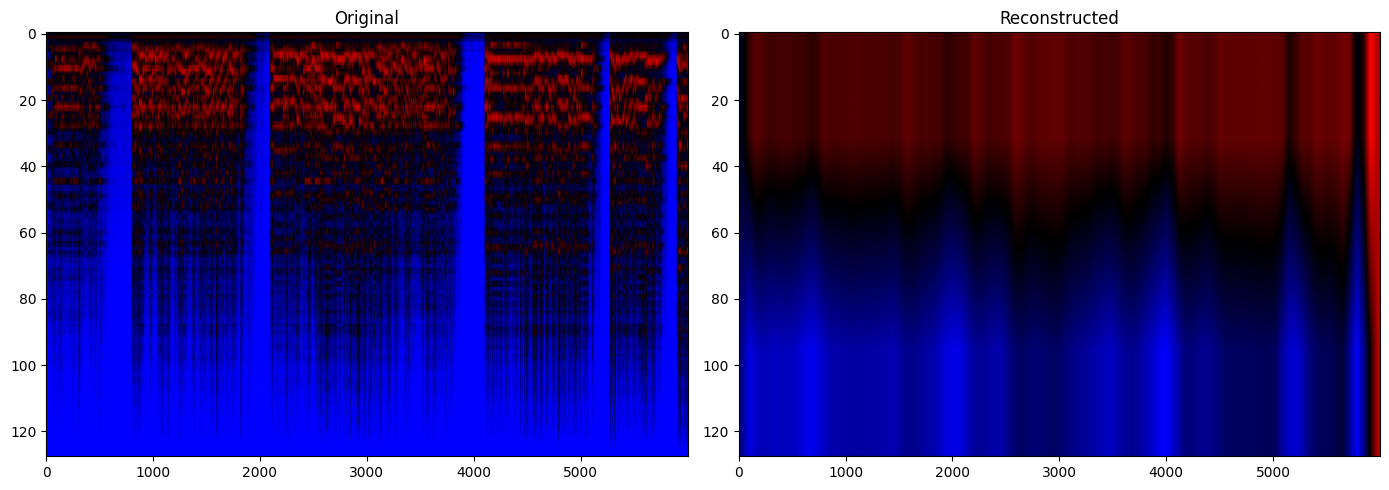

In [23]:
data1_cpu = data1.detach().cpu()
data_reconstructed_cpu = data_reconstructed.detach().cpu()
cmap = cmap2 = mpl.colors.LinearSegmentedColormap.from_list('my_colormap', ['blue', 'black', 'red'], 256)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(data1_cpu, cmap=cmap, aspect='auto')
axes[0].set_title('Original')
axes[1].imshow(data_reconstructed_cpu, cmap=cmap, aspect='auto')
axes[1].set_title('Reconstructed')
plt.tight_layout()
data1_cpu.shape, data_reconstructed_cpu.shape